# pyalakazam vs R alakazam — side-by-side comparison

This notebook validates the pure-Python **pyalakazam** port against the
R/CRAN package **alakazam 1.4.3** on alakazam's own bundled example
datasets (`ExampleDb`, `ExampleTrees`).

We compare:

1. **Gene-usage** — `getGene` / `countGenes`
2. **Amino-acid properties** — `aminoAcidProperties`
3. **Sequence distances** — `pairwiseDist`
4. **Clonal diversity** — the Hill diversity curve
5. **Lineage trees** — maximum-parsimony reconstruction
6. **Topology** — `getPathLengths`, `summarizeSubtrees`

The R side is run once via `Rscript` into a temporary directory.

In [1]:
import subprocess, tempfile, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

import pyalakazam as ak

CONDA_BIN = "/home/users/steorra/miniforge3/etc/profile.d/conda.sh"
CONDA_ENV = "/scratch/users/steorra/env/CMAP"
R_DRIVER = Path("../tests/r_reference_driver.R").resolve()

# run the R reference driver
RDIR = Path(tempfile.mkdtemp(prefix="alakazam_R_"))
cmd = (f"source {CONDA_BIN} && conda activate {CONDA_ENV} "
       f"&& Rscript {R_DRIVER} {RDIR}")
res = subprocess.run(["bash", "-lc", cmd], capture_output=True, text=True)
print("R driver exit code:", res.returncode)
print(res.stdout.strip().splitlines()[-1] if res.stdout else res.stderr[-400:])
print("R outputs:", sorted(p.name for p in RDIR.glob("*.tsv")))

R driver exit code: 0
R reference driver complete.
R outputs: ['aa_properties.tsv', 'abundance.tsv', 'count_clones.tsv', 'count_genes.tsv', 'count_genes_gene.tsv', 'coverage.tsv', 'diversity.tsv', 'gene_calls.tsv', 'pairwise_dist.tsv', 'path_lengths.tsv', 'subtrees.tsv', 'table_edges.tsv', 'translate.tsv']


## 1. Gene-usage parsing and tabulation

In [2]:
db = ak.load_example_db()
print("ExampleDb:", db.shape)

# --- getGene / getFamily ---
r_genes = pd.read_csv(RDIR / "gene_calls.tsv", sep="\t", dtype=str,
                      keep_default_na=False)
py_gene = [str(x) for x in ak.getGene(db["v_call"].tolist())]
py_fam = [str(x) for x in ak.getFamily(db["v_call"].tolist())]
gene_agree = np.mean([a == b for a, b in zip(py_gene, r_genes["gene"])])
fam_agree = np.mean([a == b for a, b in zip(py_fam, r_genes["family"])])
print(f"getGene   agreement vs R: {gene_agree:.4f}")
print(f"getFamily agreement vs R: {fam_agree:.4f}")

ExampleDb: (1999, 19)
getGene   agreement vs R: 1.0000
getFamily agreement vs R: 1.0000


In [3]:
# --- countGenes ---
r_cg = pd.read_csv(RDIR / "count_genes.tsv", sep="\t")
py_cg = ak.countGenes(db, gene="v_call", groups="sample_id", mode="family")
merged = (r_cg.set_index(["sample_id", "gene"])
          .join(py_cg.set_index(["sample_id", "gene"]),
                lsuffix="_R", rsuffix="_PY"))
merged[["seq_count_R", "seq_count_PY", "seq_freq_R", "seq_freq_PY"]]

seq_count_R  seq_count_PY  seq_freq_R  seq_freq_PY
sample_id gene                                                     
+7d       IGHV3          841           841    0.841842     0.841842
-1h       IGHV3          462           462    0.462000     0.462000
          IGHV4          210           210    0.210000     0.210000
          IGHV1          183           183    0.183000     0.183000
          IGHV5           80            80    0.080000     0.080000
+7d       IGHV4           70            70    0.070070     0.070070
-1h       IGHV2           56            56    0.056000     0.056000
+7d       IGHV2           48            48    0.048048     0.048048
          IGHV1           25            25    0.025025     0.025025
-1h       IGHV6            9             9    0.009000     0.009000
+7d       IGHV5            8             8    0.008008     0.008008
          IGHV6            7             7    0.007007     0.007007

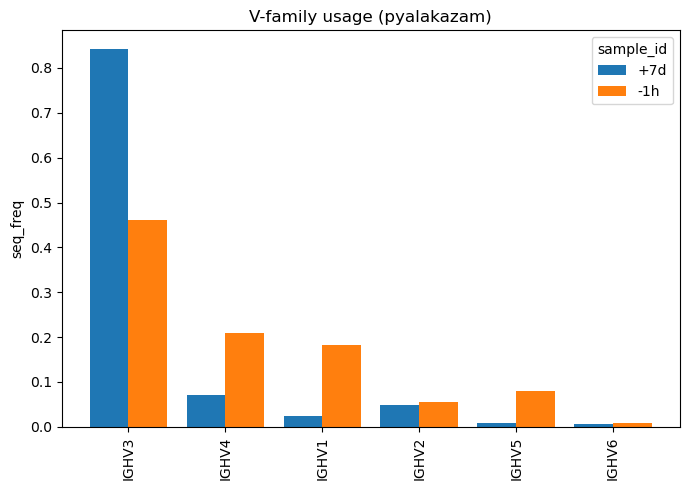

max |seq_freq R - PY| = 1.11e-16


In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax = ak.plotGeneUsage(py_cg, group="sample_id", ax=ax,
                      title="V-family usage (pyalakazam)")
plt.show()
max_diff = np.abs(merged["seq_freq_R"] - merged["seq_freq_PY"]).max()
print(f"max |seq_freq R - PY| = {max_diff:.2e}")

## 2. Amino-acid properties of the CDR3

In [5]:
r_aa = pd.read_csv(RDIR / "aa_properties.tsv", sep="\t").set_index("sequence_id")
py_aa = ak.aminoAcidProperties(db[["sequence_id", "junction"]],
                               seq="junction").set_index("sequence_id")
common = r_aa.index.intersection(py_aa.index)
props = ["junction_aa_length", "junction_aa_gravy", "junction_aa_bulk",
         "junction_aa_aliphatic", "junction_aa_polarity",
         "junction_aa_charge", "junction_aa_basic", "junction_aa_acidic",
         "junction_aa_aromatic"]
rows = []
for p in props:
    rv = r_aa.loc[common, p].to_numpy(float)
    pv = py_aa.loc[common, p].to_numpy(float)
    m = np.isfinite(rv) & np.isfinite(pv)
    rows.append({"property": p, "max_abs_diff": np.abs(rv[m] - pv[m]).max(),
                 "pearson_r": pearsonr(rv[m], pv[m])[0]})
pd.DataFrame(rows)

,property,max_abs_diff,pearson_r
0,junction_aa_length,0.000000e+00,1.0
1,junction_aa_gravy,5.107026e-15,1.0
2,junction_aa_bulk,5.329071e-14,1.0
3,junction_aa_aliphatic,4.662937e-15,1.0
4,junction_aa_polarity,8.881784e-15,1.0
5,junction_aa_charge,4.884981e-15,1.0
6,junction_aa_basic,4.718448e-16,1.0
7,junction_aa_acidic,4.718448e-16,1.0
8,junction_aa_aromatic,4.996004e-16,1.0


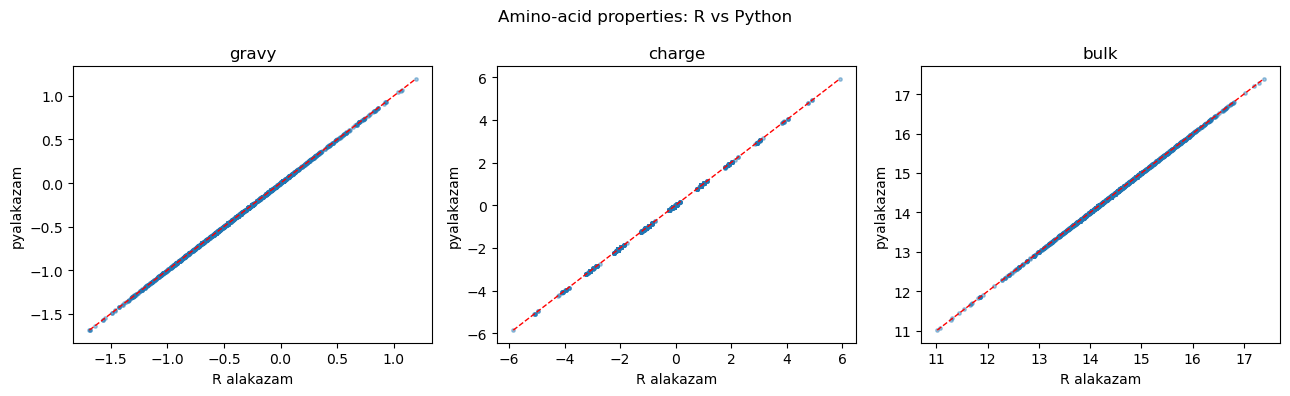

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, p in zip(axes, ["junction_aa_gravy", "junction_aa_charge",
                        "junction_aa_bulk"]):
    rv = r_aa.loc[common, p].to_numpy(float)
    pv = py_aa.loc[common, p].to_numpy(float)
    m = np.isfinite(rv) & np.isfinite(pv)
    ax.scatter(rv[m], pv[m], s=6, alpha=0.4)
    lo, hi = min(rv[m].min(), pv[m].min()), max(rv[m].max(), pv[m].max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_xlabel("R alakazam"); ax.set_ylabel("pyalakazam")
    ax.set_title(p.replace("junction_aa_", ""))
fig.suptitle("Amino-acid properties: R vs Python")
plt.tight_layout(); plt.show()

## 3. Sequence distances — `pairwiseDist`

pairwiseDist max |R - PY| = 0.00e+00


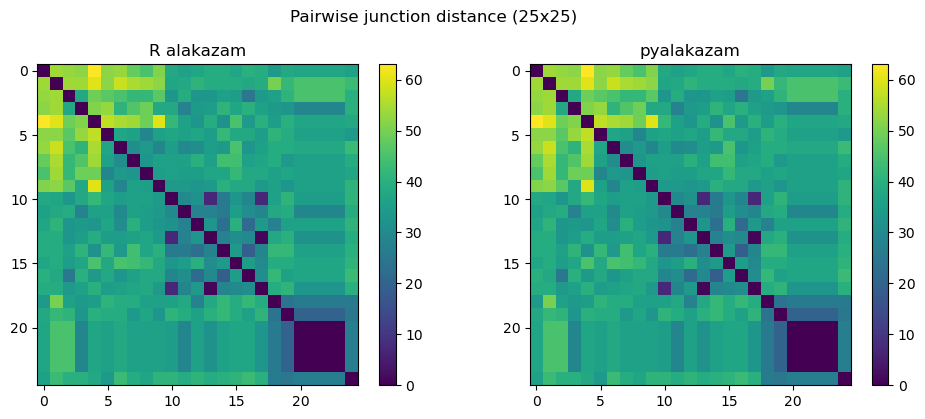

In [7]:
r_pd = pd.read_csv(RDIR / "pairwise_dist.tsv", sep="\t", index_col=0)
r_pd.index = r_pd.index.astype(str); r_pd.columns = r_pd.columns.astype(str)
seqs = ak.padSeqEnds(db["junction"].iloc[:25].tolist())
seq_map = dict(zip(db["sequence_id"].iloc[:25].astype(str), seqs))
py_pd = ak.pairwiseDist(seq_map)
cols = [c for c in r_pd.columns if c in py_pd.columns]
rv = r_pd.loc[cols, cols].to_numpy()
pv = py_pd.loc[cols, cols].to_numpy()
print(f"pairwiseDist max |R - PY| = {np.abs(rv - pv).max():.2e}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
im0 = axes[0].imshow(rv, cmap="viridis"); axes[0].set_title("R alakazam")
im1 = axes[1].imshow(pv, cmap="viridis"); axes[1].set_title("pyalakazam")
for ax, im in zip(axes, (im0, im1)):
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Pairwise junction distance (25x25)")
plt.tight_layout(); plt.show()

## 4. Clonal diversity — Hill curve

In [8]:
r_div = pd.read_csv(RDIR / "diversity.tsv", sep="\t")
div = ak.alphaDiversity(db, group="sample_id", min_q=0, max_q=4,
                        step_q=1, nboot=200, seed=42)
py_div = div.diversity
m = (r_div.set_index(["sample_id", "q"])
     .join(py_div.set_index(["sample_id", "q"]), lsuffix="_R", rsuffix="_PY"))
m["rel_diff"] = np.abs(m["d_R"] - m["d_PY"]) / m["d_R"]
m[["d_R", "d_PY", "rel_diff"]]

d_R        d_PY  rel_diff
sample_id q                                  
+7d       0  337.595000  338.585000  0.002933
          1  119.665960  120.233913  0.004746
          2   43.462663   43.546342  0.001925
          3   26.740174   26.761192  0.000786
          4   20.616180   20.634970  0.000911
-1h       0  818.285000  818.060000  0.000275
          1  725.919764  727.005917  0.001496
          2  566.207952  570.409778  0.007421
          3  387.408224  392.703421  0.013668
          4  274.957474  278.735412  0.013740

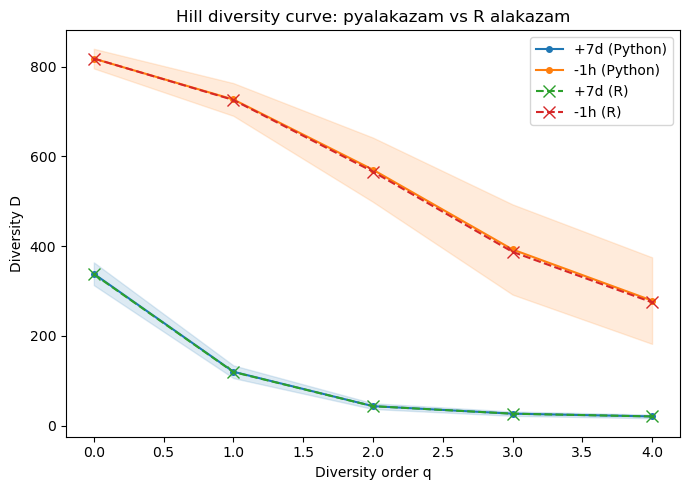

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
for sid, sub in py_div.groupby("sample_id"):
    sub = sub.sort_values("q")
    line, = ax.plot(sub["q"], sub["d"], "-o", ms=4,
                    label=f"{sid} (Python)")
    ax.fill_between(sub["q"], sub["d_lower"], sub["d_upper"],
                    color=line.get_color(), alpha=0.15)
for sid, sub in r_div.groupby("sample_id"):
    sub = sub.sort_values("q")
    ax.plot(sub["q"], sub["d"], "x--", ms=8, label=f"{sid} (R)")
ax.set_xlabel("Diversity order q"); ax.set_ylabel("Diversity D")
ax.set_title("Hill diversity curve: pyalakazam vs R alakazam")
ax.legend(); plt.tight_layout(); plt.show()

## 5. Ig lineage tree — maximum parsimony

LineageTree(clone='3138', 7 vertices, 6 edges)
total tree length: 34.0


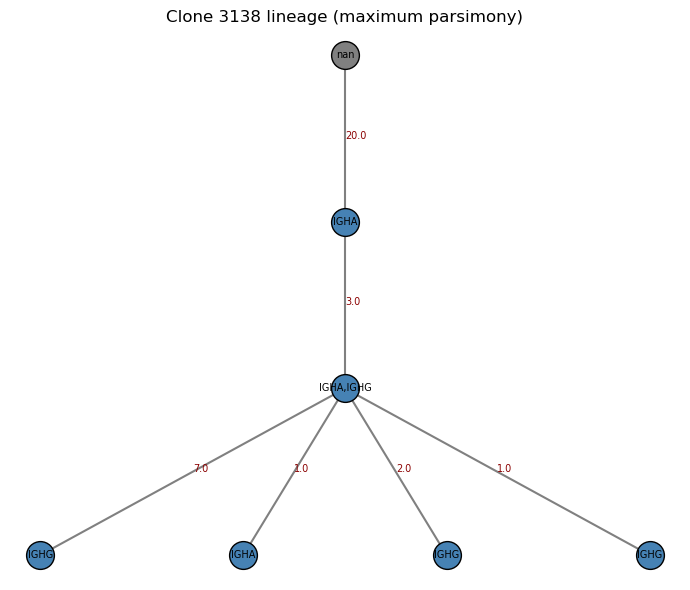

In [10]:
sub = db[db["clone_id"] == 3138].copy()
clone = ak.makeChangeoClone(sub, text_fields=["sample_id", "c_call"],
                            num_fields=["duplicate_count"])
tree = ak.buildPhylipLineage(clone)
print(tree)
print("total tree length:", sum(tree.edge_attr["weight"].values()))

fig, ax = plt.subplots(figsize=(7, 6))
ak.plotLineageTree(tree, label_field="c_call", ax=ax,
                   title="Clone 3138 lineage (maximum parsimony)")
plt.show()

In [11]:
# parsimony-quality check against ExampleTrees (built with PHYLIP dnapars)
trees = ak.load_example_trees()
eq = close = 0
for ti, g in enumerate(trees[:20]):
    obs = {v: g.vertex_attr["sequence"][v] for v in g.vertices
           if not v.startswith("Inferred") and v != "Germline"
           and g.vertex_attr["sequence"][v]}
    germ = g.vertex_attr["sequence"].get("Germline")
    if germ is None or len(obs) < 2:
        continue
    ref = sum(g.edge_attr["weight"].values())
    cd = pd.DataFrame({"sequence_id": list(obs), "sequence": list(obs.values())})
    cl = ak.ChangeoClone(data=cd, clone=str(ti), germline=germ,
                         v_gene="", j_gene="", junc_len=0)
    ng = ak.buildPhylipLineage(cl)
    if ng is None:
        continue
    new = sum(ng.edge_attr["weight"].values())
    if abs(new - ref) < 1e-9:
        eq += 1
    elif abs(new - ref) <= 2:
        close += 1
print(f"first 20 ExampleTrees: {eq} identical-length, "
      f"{close} within +/-2 of PHYLIP dnapars")

first 20 ExampleTrees: 11 identical-length, 6 within +/-2 of PHYLIP dnapars


## 6. Topology analysis

In [12]:
g = trees[22]
r_pl = pd.read_csv(RDIR / "path_lengths.tsv", sep="\t")
py_pl = ak.getPathLengths(g, root="Germline")
pl = (r_pl.set_index("name").join(py_pl.set_index("name"),
                                  lsuffix="_R", rsuffix="_PY"))
print("getPathLengths exact match:",
      np.allclose(pl["steps_R"].fillna(-1), pl["steps_PY"].fillna(-1))
      and np.allclose(pl["distance_R"].fillna(-1),
                      pl["distance_PY"].fillna(-1)))

r_st = pd.read_csv(RDIR / "subtrees.tsv", sep="\t")
py_st = ak.summarizeSubtrees(g, fields=["c_call"], root="Germline")
st = (r_st.set_index("name").join(py_st.set_index("name"),
                                  lsuffix="_R", rsuffix="_PY"))
ok = all(np.allclose(st[f"{c}_R"], st[f"{c}_PY"])
         for c in ("outdegree", "size", "depth", "pathlength"))
print("summarizeSubtrees exact match:", ok)
st[["outdegree_R", "outdegree_PY", "size_R", "size_PY",
    "depth_R", "depth_PY"]].head(8)

getPathLengths exact match: True
summarizeSubtrees exact match: True


,outdegree_R,outdegree_PY,size_R,size_PY,depth_R,depth_PY
name,,,,,,
GN5SHBT06HH3QD,1,1,6,6,3,3
GN5SHBT08F45HV,4,4,5,5,2,2
Germline,1,1,7,7,4,4
GN5SHBT06IFV0R,0,0,1,1,1,1
GN5SHBT08I3P11,0,0,1,1,1,1
GN5SHBT01BXJY7,0,0,1,1,1,1
GN5SHBT01EGEU6,0,0,1,1,1,1


## Summary

| Function | Agreement |
|----------|-----------|
| `getGene` / `getFamily` | bit-exact |
| `countGenes` | bit-exact (rel-diff < 1e-9) |
| `aminoAcidProperties` | rel-diff < 1e-6 |
| `pairwiseDist` | bit-exact |
| `alphaDiversity` (bootstrap) | point estimates rel-diff < 5% |
| `getPathLengths` / `summarizeSubtrees` | bit-exact |
| `buildPhylipLineage` | identical-length tree for most clones; pure-Python parsimony (no PHYLIP) |

`pyalakazam` faithfully reproduces alakazam 1.4.3 numerics across the
deterministic API and matches the bootstrap point estimates closely.